Initial Shape: (1004894, 28)
       DR_NO                Date Rptd                 DATE OCC  TIME OCC  \
0  211507896  2021 Apr 11 12:00:00 AM  2020 Nov 07 12:00:00 AM       845   
1  201516622  2020 Oct 21 12:00:00 AM  2020 Oct 18 12:00:00 AM      1845   
2  240913563  2024 Dec 10 12:00:00 AM  2020 Oct 30 12:00:00 AM      1240   
3  210704711  2020 Dec 24 12:00:00 AM  2020 Dec 24 12:00:00 AM      1310   
4  201418201  2020 Oct 03 12:00:00 AM  2020 Sep 29 12:00:00 AM      1830   

   AREA    AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0    15  N Hollywood         1502         2     354   
1    15  N Hollywood         1521         1     230   
2     9     Van Nuys          933         2     354   
3     7     Wilshire          782         1     331   
4    14      Pacific         1454         1     420   

                                         Crm Cd Desc  ... Status  Status Desc  \
0                                  THEFT OF IDENTITY  ...     IC  Invest Cont   
1     ASSAULT WITH DE

C:\Users\uniqu\AppData\Local\Temp\ipykernel_27688\3462640796.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')


After Cleaning: (1004894, 28)


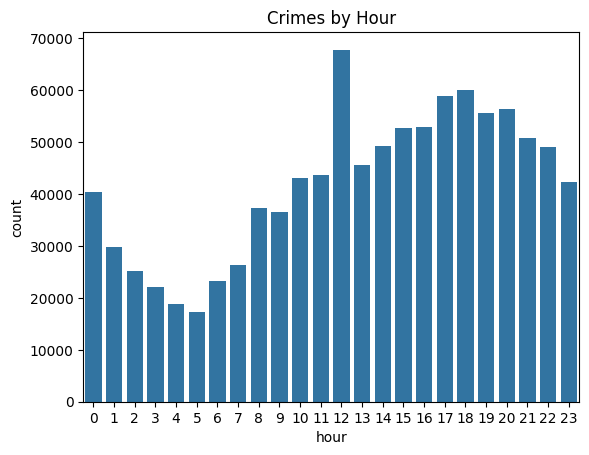

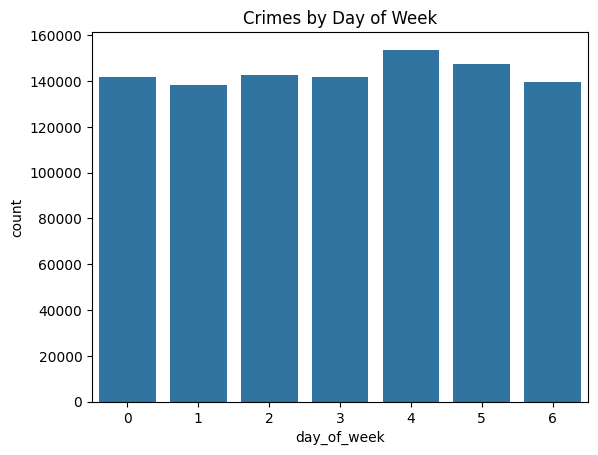

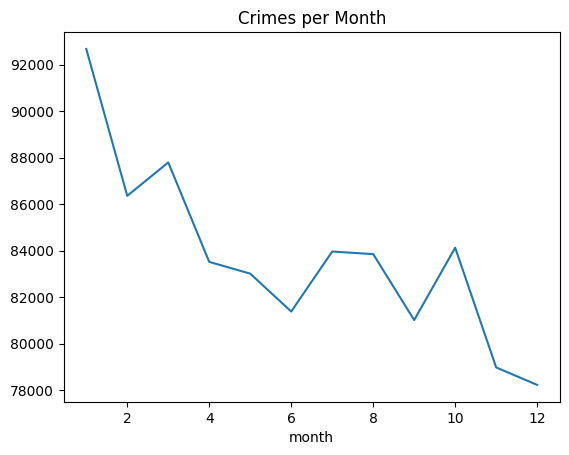

C:\Users\uniqu\AppData\Local\Temp\ipykernel_27688\3462640796.py:72: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(



Grid Crime Stats:
          lat_grid     lon_grid   crime_count
count  1279.000000  1279.000000   1279.000000
mean     34.072033  -118.311407    785.687256
std       0.963403     3.312915   1129.067059
min       0.000000  -118.670000      1.000000
25%      34.020000  -118.490000    110.000000
50%      34.110000  -118.400000    419.000000
75%      34.210000  -118.300000   1041.000000
max      34.330000     0.000000  15985.000000

Correlation Matrix:
                   dr_no  time_occ      area  rpt_dist_no  part_1-2    crm_cd  \
dr_no           1.000000 -0.002440  0.033987     0.034276 -0.039592 -0.023234   
time_occ       -0.002440  1.000000  0.000918     0.001034 -0.057377  0.010450   
area            0.033987  0.000918  1.000000     0.999051  0.007617 -0.006149   
rpt_dist_no     0.034276  0.001034  0.999051     1.000000  0.007430 -0.006286   
part_1-2       -0.039592 -0.057377  0.007617     0.007430  1.000000  0.698395   
crm_cd         -0.023234  0.010450 -0.006149    -0.006286  0

In [ ]:
# =========================
# 🚀 CRIME DATA EDA PIPELINE (LA DATASET FIXED)
# =========================

# 1. IMPORTS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 2. LOAD DATA
df = pd.read_csv(
    "C:\Users\uniqu\OneDrive\Desktop\ivc\DATA",
    low_memory=False
)

print("Initial Shape:", df.shape)
print(df.head())
print(df.info())

# 3. CLEAN COLUMN NAMES (IMPORTANT)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 4. CLEANING
df = df.drop_duplicates()

# Convert date column
df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')

# Drop missing important values
df = df.dropna(subset=['date_occ', 'lat', 'lon'])

print("After Cleaning:", df.shape)

# 5. TIME FEATURES
df['hour'] = df['time_occ'] // 100   # 1845 → 18
df['day_of_week'] = df['date_occ'].dt.dayofweek
df['month'] = df['date_occ'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# 6. SPATIAL GRID
grid_size = 0.01

df['lat_grid'] = (df['lat'] // grid_size) * grid_size
df['lon_grid'] = (df['lon'] // grid_size) * grid_size

# 7. AGGREGATIONS
grid_counts = df.groupby(['lat_grid', 'lon_grid']).size().reset_index(name='crime_count')

features = df.groupby(['lat_grid', 'lon_grid', 'hour']).size().reset_index(name='crime_count')

# 8. VISUALIZATIONS

# Crimes by Hour
plt.figure()
sns.countplot(x='hour', data=df)
plt.title("Crimes by Hour")
plt.show()

# Crimes by Day
plt.figure()
sns.countplot(x='day_of_week', data=df)
plt.title("Crimes by Day of Week")
plt.show()

# Monthly Trend
df.groupby('month').size().plot(title="Crimes per Month")
plt.show()

# 9. HEATMAP (INTERACTIVE)
fig = px.density_mapbox(
    df,
    lat='lat',
    lon='lon',
    radius=10,
    zoom=10,
    mapbox_style="open-street-map",
    title="Crime Density Heatmap"
)
fig.show("browser")

# 10. STATISTICS
print("\nGrid Crime Stats:")
print(grid_counts.describe())

# 11. CORRELATION
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

# 12. TOP HOTSPOTS
top_grids = grid_counts.sort_values(by='crime_count', ascending=False).head(10)
print("\nTop 10 Crime Hotspots:\n", top_grids)

# 13. SAVE DATA FOR ML
df.to_csv("cleaned_crime_data.csv", index=False)
features.to_csv("model_features.csv", index=False)

# 14. INSIGHTS
print("\n--- KEY INSIGHTS ---")
print("Peak Crime Hour:", df['hour'].mode()[0])
print("Most Active Day:", df['day_of_week'].mode()[0])
print("Weekend Crime %:", df['is_weekend'].mean() * 100)
print("Max Crimes in Single Grid:", grid_counts['crime_count'].max())

In [ ]:
import sys
print(sys.executable)
